In [ ]:
# Lab 05: OLS and Gradient Descent for Linear Regression

**Course:** Machine Learning  
**Topic:** Ordinary Least Squares and Gradient Descent  
**Name:** Bhumi Jain  
**Roll No.:** 24B5018

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import pandas as pd

In [2]:
X = np.array([0.5, 2.3, 2.9])
y = np.array([1.4, 1.9, 3.2])

print("X:", X)
print("y:", y)
print("Number of samples:", len(X))

X: [0.5 2.3 2.9]
y: [1.4 1.9 3.2]
Number of samples: 3


In [ ]:
## 1. Ordinary Least Squares (OLS)

OLS estimates the slope and intercept analytically by minimizing the sum of squared errors.

In [3]:
def ols_linear_regression(X, y):
    x_mean = np.mean(X)
    y_mean = np.mean(y)

    numerator = np.sum((X - x_mean) * (y - y_mean))
    denominator = np.sum((X - x_mean) ** 2)

    m = numerator / denominator
    c = y_mean - m * x_mean

    return m, c

In [4]:
m_ols, c_ols = ols_linear_regression(X, y)

print("OLS slope (m):", m_ols)
print("OLS intercept (c):", c_ols)

OLS slope (m): 0.6410256410256411
OLS intercept (c): 0.9487179487179487


In [5]:
y_pred_ols = m_ols * X + c_ols

print("Actual y:", y)
print("Predicted y:", y_pred_ols)

Actual y: [1.4 1.9 3.2]
Predicted y: [1.26923077 2.42307692 2.80769231]


In [6]:
## 2. Batch Gradient Descent

Gradient Descent iteratively updates the slope and intercept to minimize the mean squared error.

SyntaxError: invalid syntax (909273283.py, line 3)

In [7]:
def gradient_descent(X, y, alpha=0.05, epochs=1000):
    m = 0.0
    c = 0.0
    n = len(X)

    loss_history = []

    for epoch in range(epochs):
        y_pred = m * X + c

        loss = np.mean((y_pred - y) ** 2)
        loss_history.append(loss)

        dm = (2 / n) * np.sum((y_pred - y) * X)
        dc = (2 / n) * np.sum(y_pred - y)

        m = m - alpha * dm
        c = c - alpha * dc

    return m, c, loss_history

In [8]:
m_gd, c_gd, loss_history = gradient_descent(
    X, y, alpha=0.05, epochs=1500
)

print("Gradient Descent slope (m):", m_gd)
print("Gradient Descent intercept (c):", c_gd)

Gradient Descent slope (m): 0.641025641025713
Gradient Descent intercept (c): 0.9487179487177796


In [9]:
print("Initial loss:", loss_history[0])
print("Final loss:", loss_history[-1])

Initial loss: 5.2700000000000005
Final loss: 0.14820512820512832


In [10]:
y_pred_gd = m_gd * X + c_gd

print("Actual y:", y)
print("GD predicted y:", y_pred_gd)

Actual y: [1.4 1.9 3.2]
GD predicted y: [1.26923077 2.42307692 2.80769231]


In [11]:
def compute_evaluation_metrics(X, y, y_pred, m):
    n = len(X)
    df = n - 2

    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)

    r2 = 1 - (ss_res / ss_tot)

    residual_variance = ss_res / df

    se_m = np.sqrt(
        residual_variance /
        np.sum((X - np.mean(X)) ** 2)
    )

    t_stat = m / se_m
    p_val = 2 * stats.t.sf(abs(t_stat), df)

    return r2, t_stat, p_val

In [12]:
r2_ols, t_ols, p_ols = compute_evaluation_metrics(
    X, y, y_pred_ols, m_ols
)

print("OLS R²:", r2_ols)
print("OLS t-statistic:", t_ols)
print("OLS p-value:", p_ols)

OLS R²: 0.7425007425007422
OLS t-statistic: 1.6980890270283098
OLS p-value: 0.33881905721007677


In [13]:
r2_gd, t_gd, p_gd = compute_evaluation_metrics(
    X, y, y_pred_gd, m_gd
)

print("GD R²:", r2_gd)
print("GD t-statistic:", t_gd)
print("GD p-value:", p_gd)

GD R²: 0.7425007425007426
GD t-statistic: 1.6980890270285018
GD p-value: 0.33881905721004535


In [14]:
comparison = pd.DataFrame({
    "Method": ["OLS", "Gradient Descent"],
    "Slope": [m_ols, m_gd],
    "Intercept": [c_ols, c_gd],
    "R²": [r2_ols, r2_gd],
    "t-statistic": [t_ols, t_gd],
    "p-value": [p_ols, p_gd]
})

comparison

,Method,Slope,Intercept,R²,t-statistic,p-value
0,OLS,0.641026,0.948718,0.742501,1.698089,0.338819
1,Gradient Descent,0.641026,0.948718,0.742501,1.698089,0.338819


In [15]:
print("Difference in slope:",
      abs(m_ols - m_gd))

print("Difference in intercept:",
      abs(c_ols - c_gd))

Difference in slope: 7.194245199571014e-14
Difference in intercept: 1.6908696665041134e-13


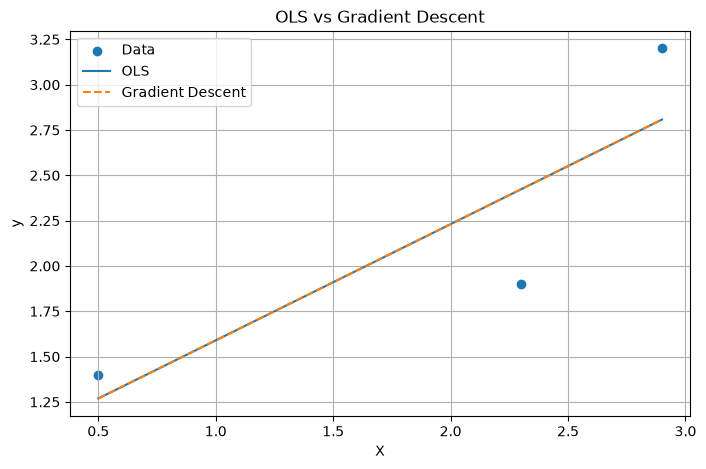

In [16]:
x_line = np.linspace(X.min(), X.max(), 100)

y_line_ols = m_ols * x_line + c_ols
y_line_gd = m_gd * x_line + c_gd

plt.figure(figsize=(8, 5))

plt.scatter(X, y, label="Data")
plt.plot(x_line, y_line_ols, label="OLS")
plt.plot(x_line, y_line_gd, linestyle="--", label="Gradient Descent")

plt.xlabel("X")
plt.ylabel("y")
plt.title("OLS vs Gradient Descent")
plt.legend()
plt.grid(True)

plt.show()

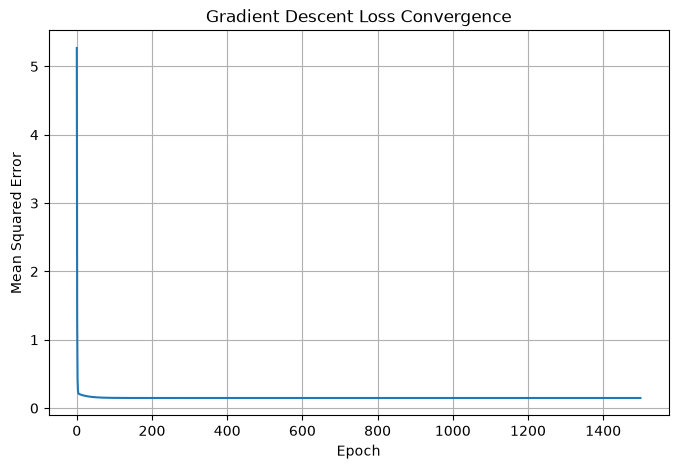

In [17]:
plt.figure(figsize=(8, 5))

plt.plot(loss_history)

plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.title("Gradient Descent Loss Convergence")
plt.grid(True)

plt.show()

In [18]:
print("Initial loss:", loss_history[0])
print("Final loss:", loss_history[-1])

if loss_history[-1] < loss_history[0]:
    print("Gradient Descent converged toward a lower loss.")
else:
    print("Loss did not decrease.")

Initial loss: 5.2700000000000005
Final loss: 0.14820512820512832
Gradient Descent converged toward a lower loss.


In [19]:
m_fast, c_fast, loss_fast = gradient_descent(
    X, y, alpha=1.0, epochs=100
)

m_slow, c_slow, loss_slow = gradient_descent(
    X, y, alpha=0.0001, epochs=1500
)

print("Alpha = 1.0")
print("Slope:", m_fast)
print("Intercept:", c_fast)
print("Final loss:", loss_fast[-1])

print("\nAlpha = 0.0001")
print("Slope:", m_slow)
print("Intercept:", c_slow)
print("Final loss:", loss_slow[-1])

Alpha = 1.0
Slope: -3.922990867173908e+99
Intercept: -1.6714141998806606e+99
Final loss: 1.0090054889457266e+198

Alpha = 0.0001
Slope: 0.6992963503801872
Intercept: 0.33546715579283437
Final loss: 0.4047008511822599


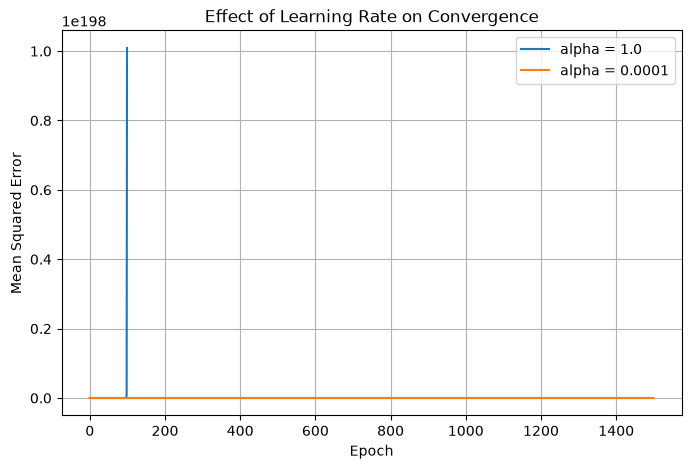

In [20]:
plt.figure(figsize=(8, 5))

plt.plot(loss_fast, label="alpha = 1.0")
plt.plot(loss_slow, label="alpha = 0.0001")

plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.title("Effect of Learning Rate on Convergence")
plt.legend()
plt.grid(True)

plt.show()

In [21]:
results = pd.DataFrame({
    "Method": ["OLS", "Gradient Descent"],
    "Slope": [m_ols, m_gd],
    "Intercept": [c_ols, c_gd],
    "R²": [r2_ols, r2_gd]
})

results

,Method,Slope,Intercept,R²
0,OLS,0.641026,0.948718,0.742501
1,Gradient Descent,0.641026,0.948718,0.742501


In [22]:
print("===== LAB 5 FINAL CHECK =====")

print("OLS slope:", m_ols)
print("OLS intercept:", c_ols)

print("GD slope:", m_gd)
print("GD intercept:", c_gd)

print("OLS R²:", r2_ols)
print("GD R²:", r2_gd)

print("Initial GD loss:", loss_history[0])
print("Final GD loss:", loss_history[-1])

print("\nLab 5 completed successfully!")

===== LAB 5 FINAL CHECK =====
OLS slope: 0.6410256410256411
OLS intercept: 0.9487179487179487
GD slope: 0.641025641025713
GD intercept: 0.9487179487177796
OLS R²: 0.7425007425007422
GD R²: 0.7425007425007426
Initial GD loss: 5.2700000000000005
Final GD loss: 0.14820512820512832

Lab 5 completed successfully!
